# FAPE, COMPAS Baseline Models
## Criminal Justice Domain, Recidivism Prediction

**Dataset:** COMPAS, ProPublica Broward County (2013-2014)  
**Records:** 6,172 (train: 4,937 | test: 1,235)  
**Target:** Two-year recidivism (1=recidivate, 0=no recidivism)  
**Sensitive attributes:** race, sex  
**Models:** Logistic Regression, Random Forest, Gradient Boosting  

**Key finding:** African-American FPR (29.3%) is 2.5x Caucasian FPR (11.3%), the same direction as ProPublica's finding for the COMPAS score, though for a different model on a different subset. Stage 2 applies ThresholdOptimizer under demographic parity and equalized odds.

In [1]:
%matplotlib inline
import sys
import os
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_loader import load_compas
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, confusion_matrix)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
os.makedirs('../figures/baseline', exist_ok=True)

MODEL_COLORS = {'LogisticRegression':'steelblue', 'RandomForest':'coral', 'GradientBoosting':'#5cb85c'}
feature_cols = ['age','c_charge_degree','sex','priors_count','days_b_screening_arrest','decile_score']
print('Imports complete')

Imports complete


In [2]:
df_raw = load_compas(data_dir='../data/raw')
df = df_raw.copy()
le = LabelEncoder()
for col in ['c_charge_degree','race','sex','score_text']:
    df[col] = le.fit_transform(df[col].astype(str))

X = df[feature_cols].values
y = df['label'].values

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, np.arange(len(y)), test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

race_test = df_raw['race'].iloc[idx_test].reset_index(drop=True)
sex_test = df_raw['sex'].iloc[idx_test].reset_index(drop=True)

MODELS = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in MODELS.items():
    if name == 'LogisticRegression':
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
        y_prob = model.predict_proba(X_test_sc)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'acc': accuracy_score(y_test, y_pred),
        'prec': precision_score(y_test, y_pred),
        'rec': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_prob)
    }
    print(f'{name}: AUC={results[name]["auc"]:.3f} F1={results[name]["f1"]:.3f}')

COMPAS loaded: 6,172 records, 6 racial groups, recidivism rate: 45.5%
LogisticRegression: AUC=0.744 F1=0.621


RandomForest: AUC=0.697 F1=0.592
GradientBoosting: AUC=0.751 F1=0.647


## 1. Model Comparison, Standard Metrics

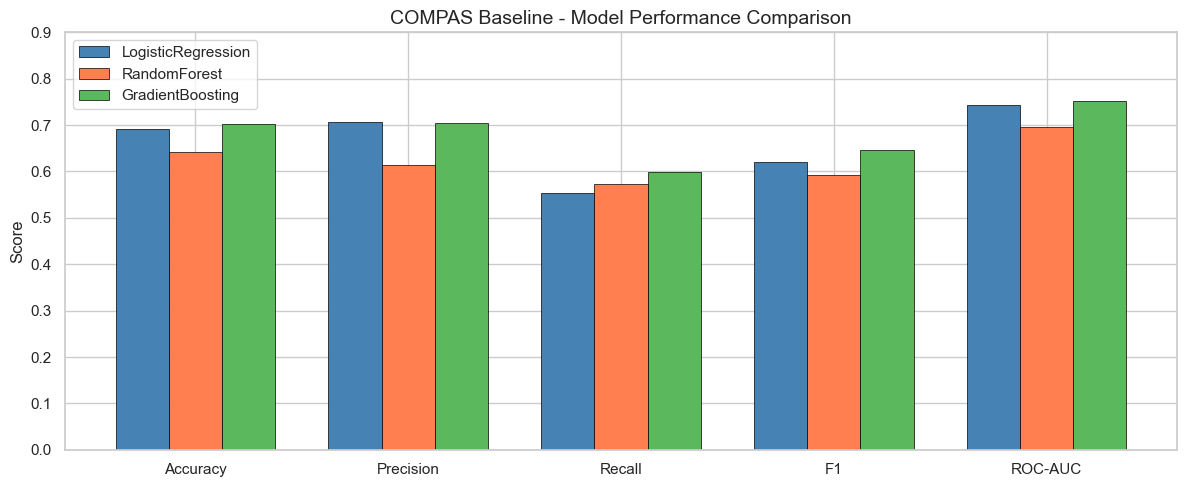

In [3]:
metrics = ['acc','prec','rec','f1','auc']
metric_labels = ['Accuracy','Precision','Recall','F1','ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12,5))
for i, (name, res) in enumerate(results.items()):
    vals = [res[m] for m in metrics]
    ax.bar(x+i*width, vals, width, label=name, color=MODEL_COLORS[name], edgecolor='black', linewidth=0.5)
ax.set_xticks(x+width)
ax.set_xticklabels(metric_labels)
ax.set_title('COMPAS Baseline - Model Performance Comparison', fontsize=14)
ax.set_ylabel('Score')
ax.set_ylim(0, 0.9)
ax.legend()
plt.tight_layout()
plt.savefig('../figures/baseline/compas_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. ROC Curves

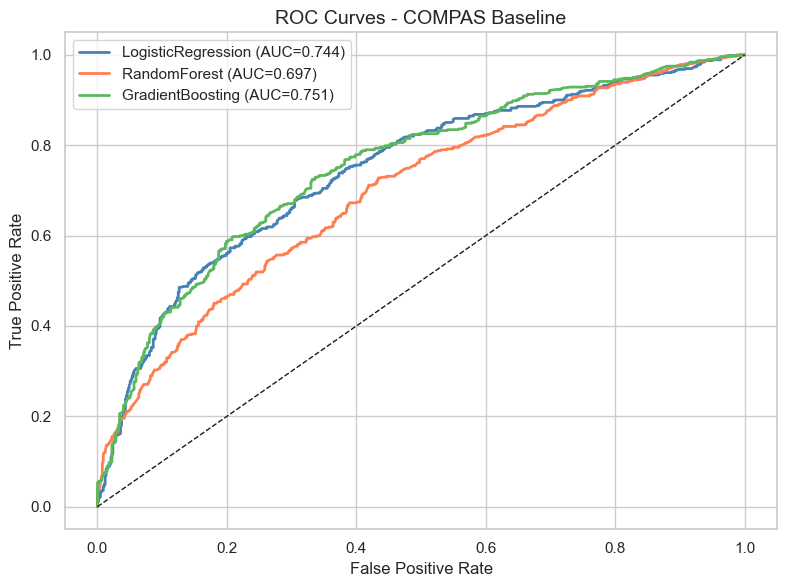

In [4]:
fig, ax = plt.subplots(figsize=(8,6))
for name, res in results.items():
    fpr_c, tpr_c, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr_c, tpr_c, label=f'{name} (AUC={res["auc"]:.3f})', color=MODEL_COLORS[name], linewidth=2)
ax.plot([0,1],[0,1],'k--', linewidth=1)
ax.set_title('ROC Curves - COMPAS Baseline', fontsize=14)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/baseline/compas_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Race FPR Comparison, Key Fairness Finding

African-American FPR is 2.5x Caucasian FPR. This is the core disparity FAPE Stage 2 targets.

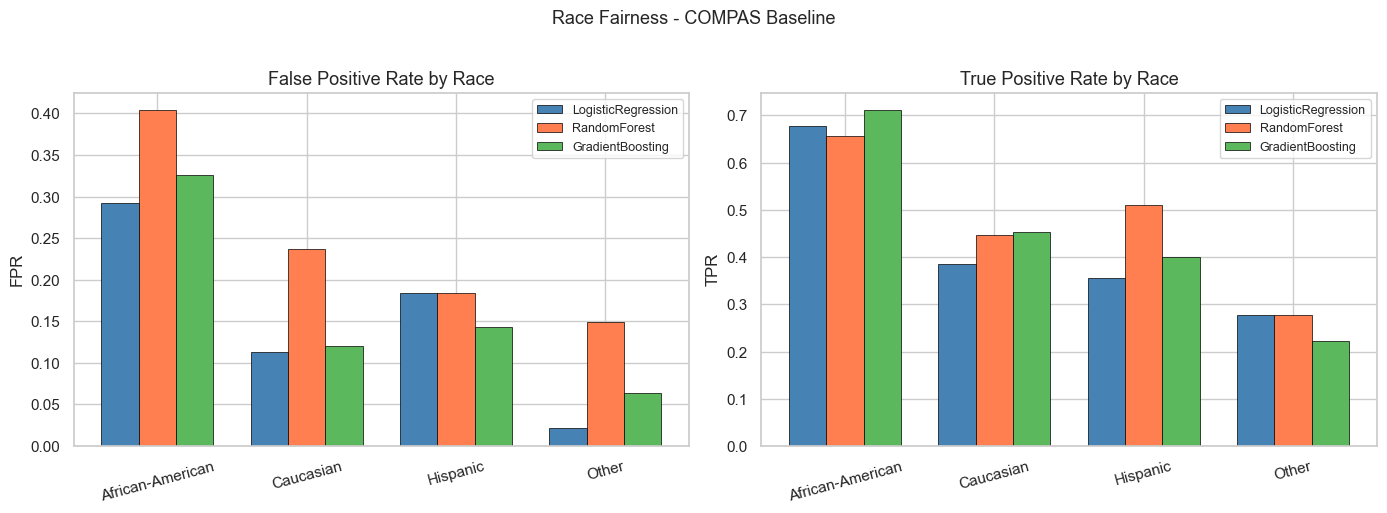

In [5]:
races = ['African-American','Caucasian','Hispanic','Other']
fpr_by_race = {}
tpr_by_race = {}
for name, res in results.items():
    fprs, tprs = [], []
    for race in races:
        mask = race_test == race
        if mask.sum() < 10:
            fprs.append(0); tprs.append(0); continue
        gp = res['y_pred'][mask]
        gt = y_test[mask]
        fprs.append(gp[gt==0].mean() if (gt==0).sum()>0 else 0)
        tprs.append(gp[gt==1].mean() if (gt==1).sum()>0 else 0)
    fpr_by_race[name] = fprs
    tpr_by_race[name] = tprs

x = np.arange(len(races))
width = 0.25
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(14,5))
for i,(name,fprs) in enumerate(fpr_by_race.items()):
    ax1.bar(x+i*width, fprs, width, label=name, color=MODEL_COLORS[name], edgecolor='black', linewidth=0.5)
ax1.set_xticks(x+width); ax1.set_xticklabels(races, rotation=15)
ax1.set_title('False Positive Rate by Race', fontsize=13)
ax1.set_ylabel('FPR'); ax1.legend(fontsize=9)
for i,(name,tprs) in enumerate(tpr_by_race.items()):
    ax2.bar(x+i*width, tprs, width, label=name, color=MODEL_COLORS[name], edgecolor='black', linewidth=0.5)
ax2.set_xticks(x+width); ax2.set_xticklabels(races, rotation=15)
ax2.set_title('True Positive Rate by Race', fontsize=13)
ax2.set_ylabel('TPR'); ax2.legend(fontsize=9)
plt.suptitle('Race Fairness - COMPAS Baseline', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/compas_race_fairness.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Demographic Parity Difference by Race

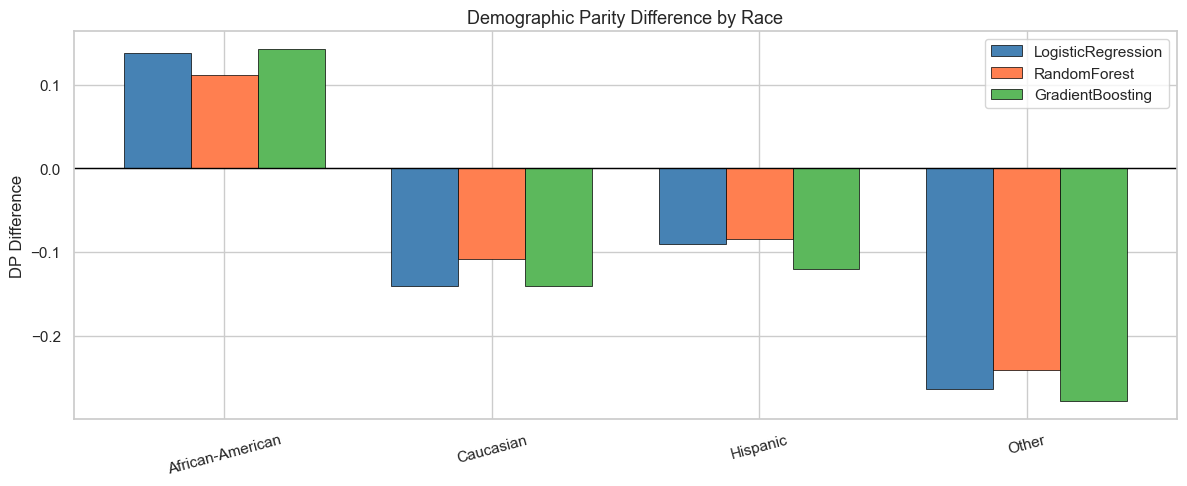

In [6]:
dp_data = {}
for name, res in results.items():
    base_rate = res['y_pred'].mean()
    dp_data[name] = [res['y_pred'][race_test==r].mean()-base_rate if (race_test==r).sum()>=10 else 0 for r in races]

x = np.arange(len(races))
width = 0.25
fig, ax = plt.subplots(figsize=(12,5))
for i,(name,dps) in enumerate(dp_data.items()):
    ax.bar(x+i*width, dps, width, label=name, color=MODEL_COLORS[name], edgecolor='black', linewidth=0.5)
ax.axhline(y=0, color='black', linewidth=1)
ax.set_xticks(x+width); ax.set_xticklabels(races, rotation=15)
ax.set_title('Demographic Parity Difference by Race', fontsize=13)
ax.set_ylabel('DP Difference'); ax.legend()
plt.tight_layout()
plt.savefig('../figures/baseline/compas_demographic_parity.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Sex Fairness

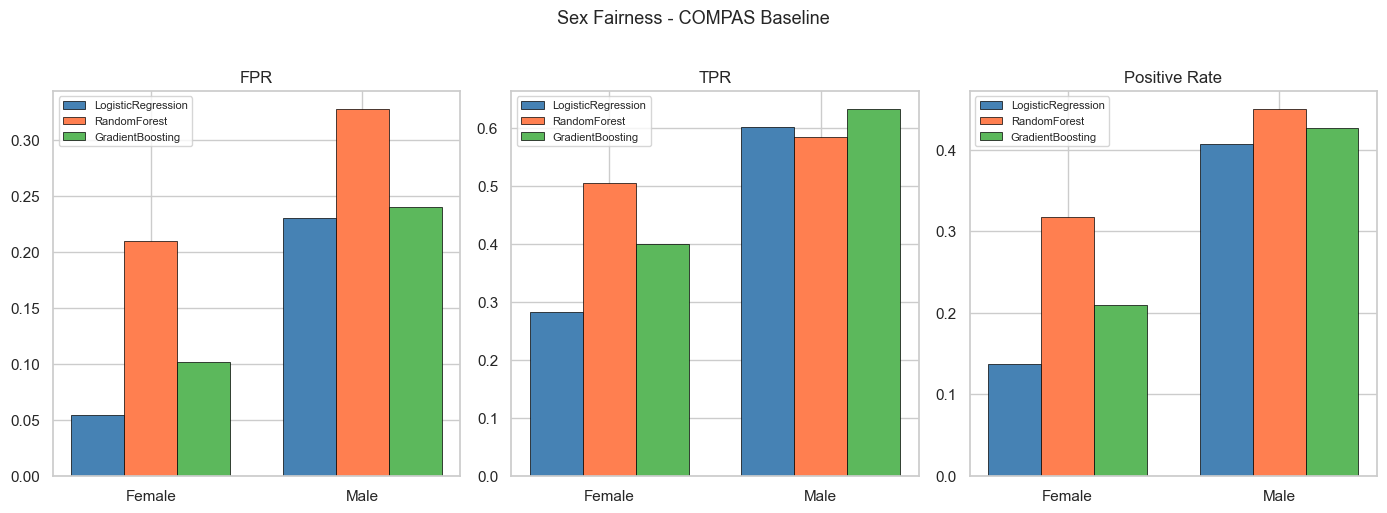

In [7]:
sexes = ['Female','Male']
sex_metrics = {}
for name, res in results.items():
    fprs,tprs,pos = [],[],[]
    for sex in sexes:
        mask = sex_test==sex
        gp = res['y_pred'][mask]; gt = y_test[mask]
        fprs.append(gp[gt==0].mean() if (gt==0).sum()>0 else 0)
        tprs.append(gp[gt==1].mean() if (gt==1).sum()>0 else 0)
        pos.append(gp.mean())
    sex_metrics[name] = {'fpr':fprs,'tpr':tprs,'pos':pos}

x = np.arange(len(sexes)); width = 0.25
fig, axes = plt.subplots(1,3, figsize=(14,5))
for ax,metric,title in zip(axes,['fpr','tpr','pos'],['FPR','TPR','Positive Rate']):
    for i,(name,sm) in enumerate(sex_metrics.items()):
        ax.bar(x+i*width, sm[metric], width, label=name, color=MODEL_COLORS[name], edgecolor='black', linewidth=0.5)
    ax.set_xticks(x+width); ax.set_xticklabels(sexes)
    ax.set_title(title); ax.legend(fontsize=8)
plt.suptitle('Sex Fairness - COMPAS Baseline', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/compas_sex_fairness.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Importance

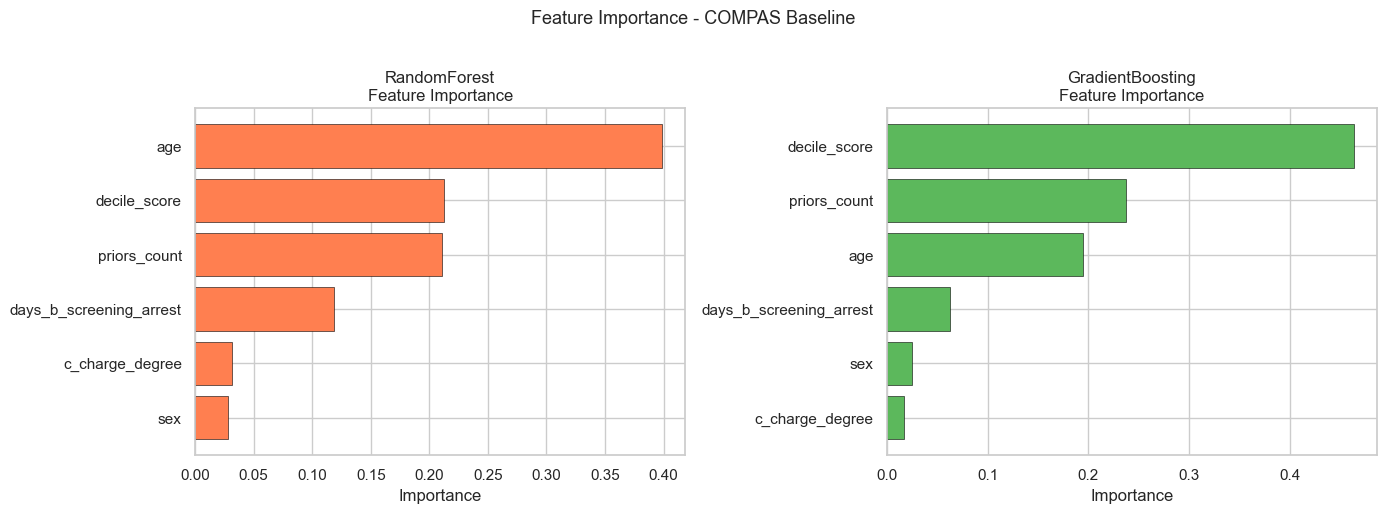

decile_score dominates, circular reference in COMPAS


In [8]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(14,5))
for ax, name in zip([ax1,ax2],['RandomForest','GradientBoosting']):
    imp = results[name]['model'].feature_importances_
    idx = np.argsort(imp)
    ax.barh([feature_cols[i] for i in idx], imp[idx], color=MODEL_COLORS[name], edgecolor='black', linewidth=0.4)
    ax.set_title(f'{name}\nFeature Importance', fontsize=12)
    ax.set_xlabel('Importance')
plt.suptitle('Feature Importance - COMPAS Baseline', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/compas_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('decile_score dominates, circular reference in COMPAS')

## 7. Confusion Matrices

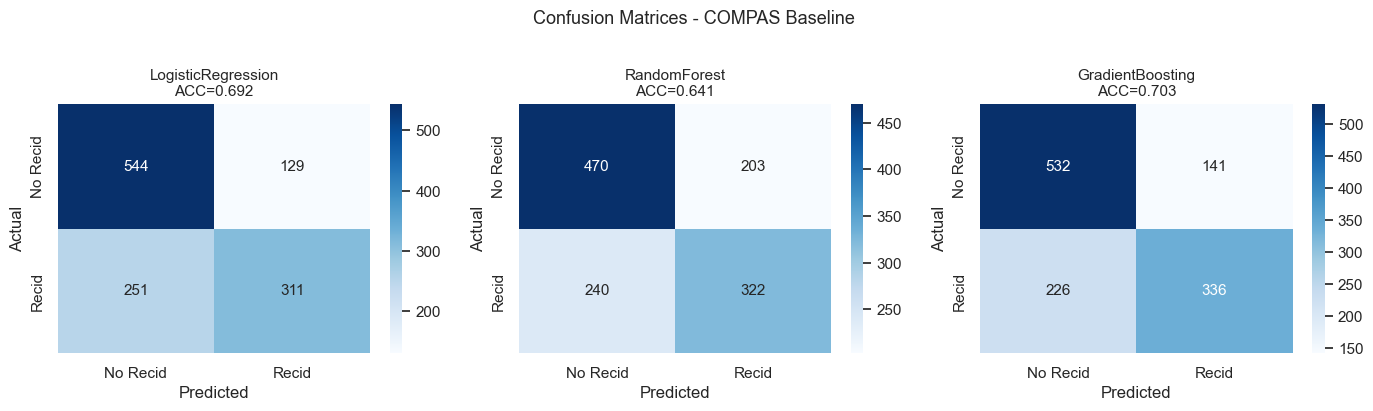

In [9]:
fig, axes = plt.subplots(1,3, figsize=(14,4))
for ax,(name,res) in zip(axes,results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Recid','Recid'], yticklabels=['No Recid','Recid'])
    ax.set_title(f'{name}\nACC={res["acc"]:.3f}', fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices - COMPAS Baseline', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/compas_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Disparate Impact Ratio by Race

DIR = positive rate (group) / positive rate (Caucasian reference). Recidivism is the adverse outcome, so the line is at 1.25, the inverse of the 0.8 four-fifths convention. African-American DIR=2.30 (LR) is massively above threshold, FAPE Stage 2 must reduce this.

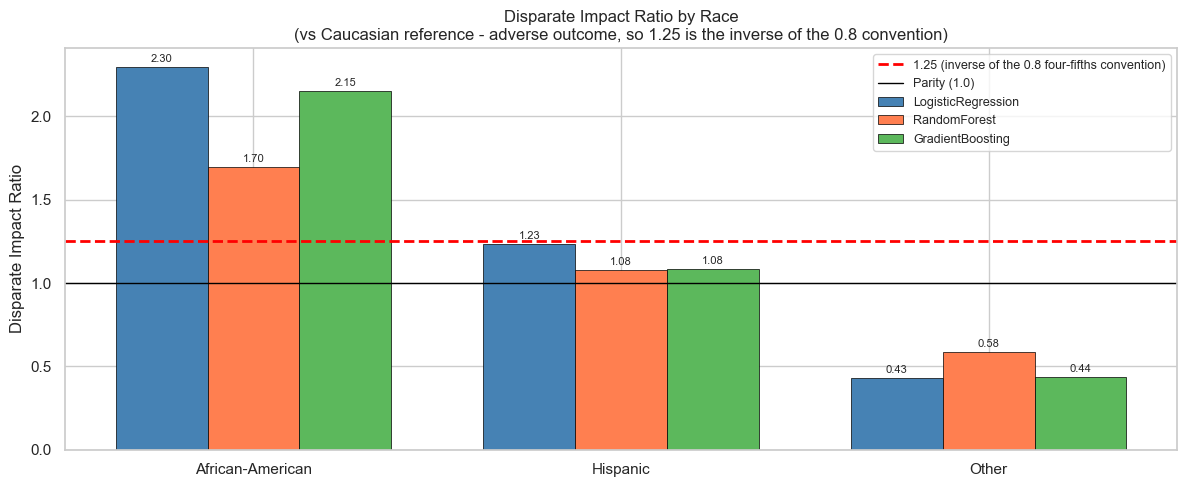

AA DIR=2.30 (LR), 2.15 (GB), massively above 1.25, the inverse of the 0.8 four-fifths convention


In [10]:
races_dir = ['African-American','Hispanic','Other']
dir_data = {}
for name, res in results.items():
    cauc_rate = res['y_pred'][race_test=='Caucasian'].mean()
    dirs = []
    for race in races_dir:
        mask = race_test == race
        if mask.sum() < 10:
            dirs.append(0); continue
        rate = res['y_pred'][mask].mean()
        dirs.append(rate / cauc_rate)
    dir_data[name] = dirs

x = np.arange(len(races_dir))
width = 0.25
fig, ax = plt.subplots(figsize=(12,5))
for i, (name, dirs) in enumerate(dir_data.items()):
    ax.bar(x+i*width, dirs, width, label=name, color=MODEL_COLORS[name], edgecolor='black', linewidth=0.5)
ax.axhline(y=1.25, color='red', linestyle='--', linewidth=2, label='1.25 (inverse of the 0.8 four-fifths convention)')
ax.axhline(y=1.0, color='black', linestyle='-', linewidth=1, label='Parity (1.0)')
ax.set_xticks(x+width)
ax.set_xticklabels(races_dir)
ax.set_title('Disparate Impact Ratio by Race\n(vs Caucasian reference - adverse outcome, so 1.25 is the inverse of the 0.8 convention)', fontsize=12)
ax.set_ylabel('Disparate Impact Ratio')
ax.legend(fontsize=9)
for i, (name, dirs) in enumerate(dir_data.items()):
    for j, val in enumerate(dirs):
        if val > 0:
            ax.text(j+i*width, val+0.03, f'{val:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/baseline/compas_disparate_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print('AA DIR=2.30 (LR), 2.15 (GB), massively above 1.25, the inverse of the 0.8 four-fifths convention')

## 9. Key Findings

**Best model:** GradientBoosting (AUC=0.751, F1=0.647).

**Race disparity:** African-American FPR (29.3%) is 2.5x Caucasian FPR (11.3%), the same direction as ProPublica's finding for the COMPAS score.

**Demographic parity:** African-American dp_diff=+0.143 (over-predicted), Other dp_diff=-0.264 (under-predicted).

**Sex fairness:** Female FPR (5.4%) far below Male FPR (23.0%).

**Feature importance:** decile_score dominates, circular reference.

**Stage 2:** applies the demographic parity and equalized odds constraints by race.